# **Load raw dataset**

In [11]:
import json
import pandas as pd
from pathlib import Path

RAW_FILE = Path("/kaggle/input/datasets/ahsanrizvimeow/amazon-product-intelligence-raw/products_full.json")

with open(RAW_FILE, encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
print(f"Loaded {len(df)} products")
df.head()

Loaded 1028 products


,search_keyword,asin,title,brand,price,rating,review_count,bullet_points,main_image_url,video_urls,reviews
0,wireless earbuds,B0D2HJDH94,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",Jxrev,$19.99,4.3 out of 5 stars,16257,[13mm dynamic speakers for a richer audio expe...,https://m.media-amazon.com/images/I/619XqESa6I...,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'Maicha', 'rating': '5 out ..."
1,wireless earbuds,B09JYJ6JKH,"Neckband Bluetooth Headphones, 24H Playtime Wi...",YOSDOM,$27.99,4.0 out of 5 stars,2856,[24 HOURS OF CONSECUTIVE PLAYBACK: You can use...,https://m.media-amazon.com/images/I/61BhENtK4I...,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'brsrafal', 'rating': '5 ou..."
2,wireless earbuds,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",Brand: XIAOWTEK,$19.99,4.6 out of 5 stars,763,[LED Power Display and 50H Playback: Dual digi...,https://m.media-amazon.com/images/I/61odQgshCW...,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'diamela', 'rating': '5 out..."
3,wireless earbuds,B0H7R1LD7B,"HAOYUYAN Wireless Earbuds, Sports Bluetooth He...",HAOYUYAN,$23.98,4.6 out of 5 stars,343,[【Sports Comfort & IPX7 Waterproof】BX17 Wirele...,https://m.media-amazon.com/images/I/71cmAChhQK...,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'Amazon Customer', 'rating'..."
4,wireless earbuds,B0G7H6K1WN,"Wireless Earbuds,Bluetooth 5.4 Ear buds,Sport ...",KTGEE,$16.99,4.7 out of 5 stars,346,"[Secure & Comfortable Earhook Fit – Flexible, ...",https://m.media-amazon.com/images/I/71eD2UACLw...,[https://m.media-amazon.com/images/S/vse-vms-t...,"[{'reviewer_name': 'Maggie Martin', 'rating': ..."


# **Inspect column types & Check null count**

In [16]:
df.info()

for col in ["price", "brand", "main_image_url"]:
    blank_count = (df[col] == "").sum()
    print(f"{col}: {blank_count} blank values")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   search_keyword  1028 non-null   object
 1   asin            1028 non-null   object
 2   title           1028 non-null   object
 3   brand           1028 non-null   object
 4   price           1028 non-null   object
 5   rating          1028 non-null   object
 6   review_count    1028 non-null   object
 7   bullet_points   1028 non-null   object
 8   main_image_url  1028 non-null   object
 9   video_urls      1028 non-null   object
 10  reviews         1028 non-null   object
 11  brand_clean     1028 non-null   object
dtypes: object(12)
memory usage: 96.5+ KB
price: 150 blank values
brand: 173 blank values
main_image_url: 1 blank values


# **Check for blank/missing values**

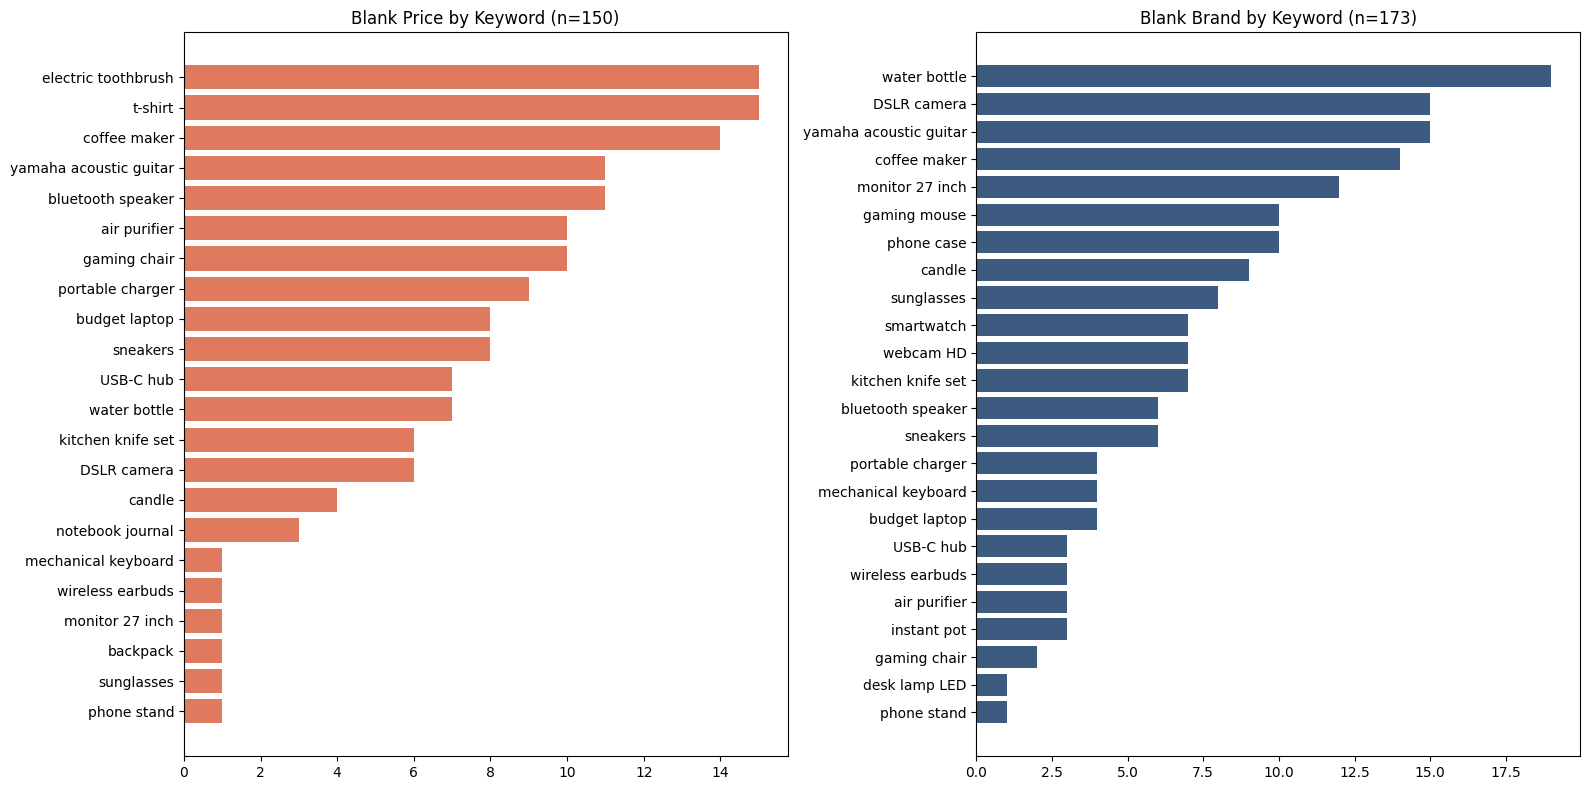

Sample rows with blank price:


,search_keyword,asin,title,brand
17,wireless earbuds,B0D9R4GYTN,"Sony WF-C510 Truly Wireless Bluetooth Earbud Headphones, Black",
46,USB-C hub,B0DXJQT19B,"Anker USB C Hub, 7in1 Multi-Port USB Adapter, 4K@60Hz USBC to HDMI Splitter",Anker
48,USB-C hub,B0DKT8BB4M,"Anker USB-C Hub, 5-in-1 USB Hub for Laptops, 4K HDMI Multiport Adapter",Anker
49,USB-C hub,B0F5HSNDXF,"Acer 10 Gbps USB C Hub, USBC Splitter with 4*USB C 3.2 and 100W PD Port",
58,USB-C hub,B087QZVQJX,"Anker USB-C Hub, 8-in-1 Multiport Ethernet Adapter with 4K@60Hz HDMI Port",Anker
59,USB-C hub,B09T9PXW35,"Hiearcool USB C Hub, USB C Dock, 4K@60Hz HDMI, 1Gbps Ethernet, Space Gray",Hiearcool
63,USB-C hub,B0GWH4ZZ7T,"Anker Nano Laptop Docking Station Dual Monitor,8-in-1 USB C Hub for Windows",Anker
64,USB-C hub,B0CN3F9Y1Z,"Acer USB Hub 4 Ports, Multiple USB 3.0 Hub, USBA Splitter for Laptop/PC 2FT",
68,mechanical keyboard,B09LK1P1RD,Logitech MX Mechanical Wireless Illuminated Keyboard Tactile - Graphite,
128,portable charger,B0H14P6BZZ,"Portable Charger, 40000mAh Power Bank with Built in Cables",Brand: Ciunedr



Duplicate ASINs found: 23


,search_keyword,asin,title
23,gaming mouse,B011HMDZ0Q,"Redragon M602 Gaming Mouse, Ergonomic RGB Gaming Mouse Wired with 7200 Adjustable DPI, 9 Programmable Buttons, Professional Software for Gamer Office [Black]"
39,gaming mouse,B011HMDZ0Q,"Redragon M602 Gaming Mouse, Ergonomic RGB Gaming Mouse Wired with 7200 Adjustable DPI, 9 Programmable Buttons, Professional Software for Gamer Office [Black]"
159,webcam HD,B07M6Y7355,"EMEET 1080P Webcam with Microphone, C960 Web Camera 2 Mics Streaming Webcam"
165,webcam HD,B07M6Y7355,"EMEET 1080P Webcam with Microphone, C960 Web Camera 2 Mics Streaming Webcam"
196,desk lamp LED,B09YV633PL,"LED Desk Lamp with Clamp, Architect Desk Lamp with Dual Light and Adjustable Swing Arm, Clip-on Eye-Care 4 CCT Modes & 5 Brightness Levels Table Light Modern Computer Lighting for Home Office"
180,desk lamp LED,B09YV633PL,"LED Desk Lamp with Clamp, Architect Desk Lamp with Dual Light and Adjustable Swing Arm, Clip-on Eye-Care 4 CCT Modes & 5 Brightness Levels Table Light Modern Computer Lighting for Home Office"
235,air purifier,B0BGPF71Q6,LEVOIT Smart Air Purifier for Home Large Room up to 1875 Ft² Vital 200S-P
246,air purifier,B0BGPF71Q6,LEVOIT Smart Air Purifier for Home Large Room up to 1875 Ft² Vital 200S-P
190,desk lamp LED,B0BNHNG5CY,"Micomlan Led Desk Lamp with Clamp, Architect Desk Lamp for Home Office with Atmosphere Lighting, 24W Ultra Bright Auto Dimming Computer Light Stepless Dimming and Tempering LED Table Light"
185,desk lamp LED,B0BNHNG5CY,"Micomlan Led Desk Lamp with Clamp, Architect Desk Lamp for Home Office with Atmosphere Lighting, 24W Ultra Bright Auto Dimming Computer Light Stepless Dimming and Tempering LED Table Light"


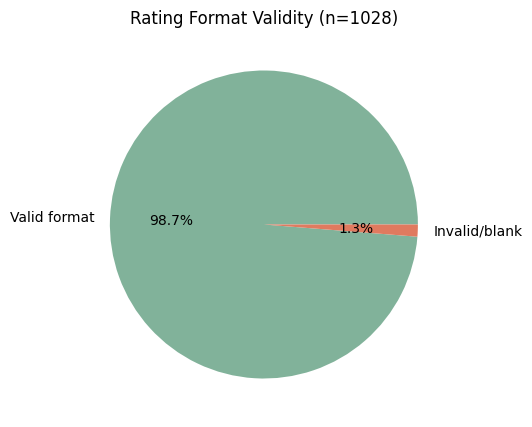


13 rows with invalid rating:


,search_keyword,asin,title,rating
334,budget laptop,B0GVPQNGS8,"dynabook Tecra A45-M 14” Business Laptop, AMD Ryzen 5 220 (Up to 4.9GHz), 16GB DDR5 RAM, 512GB SSD, WUXGA 1920x1200, Wi-Fi 7, Windows 11 Pro, AI Copilot, Thunderbolt 4, Lightweight",
339,budget laptop,B0GY16ZXZV,"HP Laptop 2026 Student Business, Copilot AI+Office 365, 128GB UFS Intel CPU",
355,budget laptop,B0GM8RB7P7,"LaunchWise: A Step-by-Step System to Launch, Organize and Scale Your Business with Clarity and Calm",
365,bluetooth speaker,B0HDN8K6GB,"Bluetooth Speaker, Portable Wireless, 20W HD Stereo Loud Sound, 8 Modes LED Light Show, 30H Playtime, IPX4 Waterproof, TWS Pairing, Built-in Mic, BT5.3, for Outdoor, Party, Travel, Home, Ideal Gifts",
370,bluetooth speaker,B0H7X6X3CR,"Hisense WeBoom - Portable Bluetooth Speaker,IP67 Waterproof, Dustproof, and Shockproof, Up to 24H Playback Time,Bass Boost,Ambient Light,Bluetooth 6.0,Auracast",
389,kitchen knife set,B0H25NYHZS,"Nice Kitchen Dinner Knives Set of 12,9.1-Inch",
422,kitchen knife set,B0HC7CLS4G,"Ninja NeverDull® Pro 11-Piece Sharpening Knife Set, Forest Sage, WK62011GN6",
459,coffee maker,B0H42JFSHP,"Ratio Eight Series 2 Drip Coffee Maker, 8-Cup Glass Carafe",
623,water bottle,B0GSH59RLD,"The Memory Company Officially Licensed NCAAPurdue University 34oz Stainless Steel Water Bottle, Team Color, Plaid Design",
746,notebook journal,B0HCMZP9H1,HOMEWORK NOTEBOOK: FUN DESIGN HOMEWORK JOURNAL,



80 rows with non-standard brand format:


,search_keyword,asin,brand
2,wireless earbuds,B0H9LHWBDK,Brand: XIAOWTEK
8,wireless earbuds,B0HBW8PTYN,Brand: Fhumsh
9,wireless earbuds,B0HDB6MTYJ,Brand: Fhumsh
10,wireless earbuds,B0H9LRGB3B,Brand: XIAOWTEK
28,gaming mouse,B0GWPXKLHB,Brand: WYQQXZYKJ
33,gaming mouse,B0DP3VPWN3,Brand: YOTETION
103,smartwatch,B0GZZVM9DX,Brand: ProTVSolutions
125,phone case,B0GSZBDJ85,Brand: Tecival
128,portable charger,B0H14P6BZZ,Brand: Ciunedr
133,portable charger,B0FTL9CR3T,Brand: Generic


In [13]:
import matplotlib.pyplot as plt
from IPython.display import display

# --- 1. Blank price / brand by keyword: side-by-side bar charts ---
blank_price_kw = df[df["price"] == ""]["search_keyword"].value_counts()
blank_brand_kw = df[df["brand"] == ""]["search_keyword"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(blank_price_kw.index, blank_price_kw.values, color="#e07a5f")
axes[0].set_title(f"Blank Price by Keyword (n={blank_price_kw.sum()})")
axes[0].invert_yaxis()

axes[1].barh(blank_brand_kw.index, blank_brand_kw.values, color="#3d5a80")
axes[1].set_title(f"Blank Brand by Keyword (n={blank_brand_kw.sum()})")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# --- 2. Sample of blank-price rows: as a clean table ---
print("Sample rows with blank price:")
display(df[df["price"] == ""][["search_keyword", "asin", "title", "brand"]].head(10)
        .style.set_properties(**{"text-align": "left"}))

# --- 3. Duplicate ASINs: table ---
dupe_counts = df["asin"].value_counts()
dupes = dupe_counts[dupe_counts > 1]
print(f"\nDuplicate ASINs found: {len(dupes)}")
display(df[df["asin"].isin(dupes.index)][["search_keyword", "asin", "title"]]
        .sort_values("asin").style.set_properties(**{"text-align": "left"}))

# --- 4. Rating format check: pie chart + table of bad ones ---
valid_rating = df["rating"].str.contains("out of 5 stars", na=False)
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([valid_rating.sum(), (~valid_rating).sum()],
       labels=["Valid format", "Invalid/blank"],
       autopct='%1.1f%%', colors=["#81b29a", "#e07a5f"])
ax.set_title(f"Rating Format Validity (n={len(df)})")
plt.show()

print(f"\n{(~valid_rating).sum()} rows with invalid rating:")
display(df[~valid_rating][["search_keyword", "asin", "title", "rating"]]
        .style.set_properties(**{"text-align": "left"}))

# --- 5. Brand format variants: table ---
brand_variants = df[df["brand"].str.contains("Brand:|Visit|Store", na=False)]
print(f"\n{len(brand_variants)} rows with non-standard brand format:")
display(brand_variants[["search_keyword", "asin", "brand"]]
        .style.set_properties(**{"text-align": "left"}))

# **Visualize data quality issues**

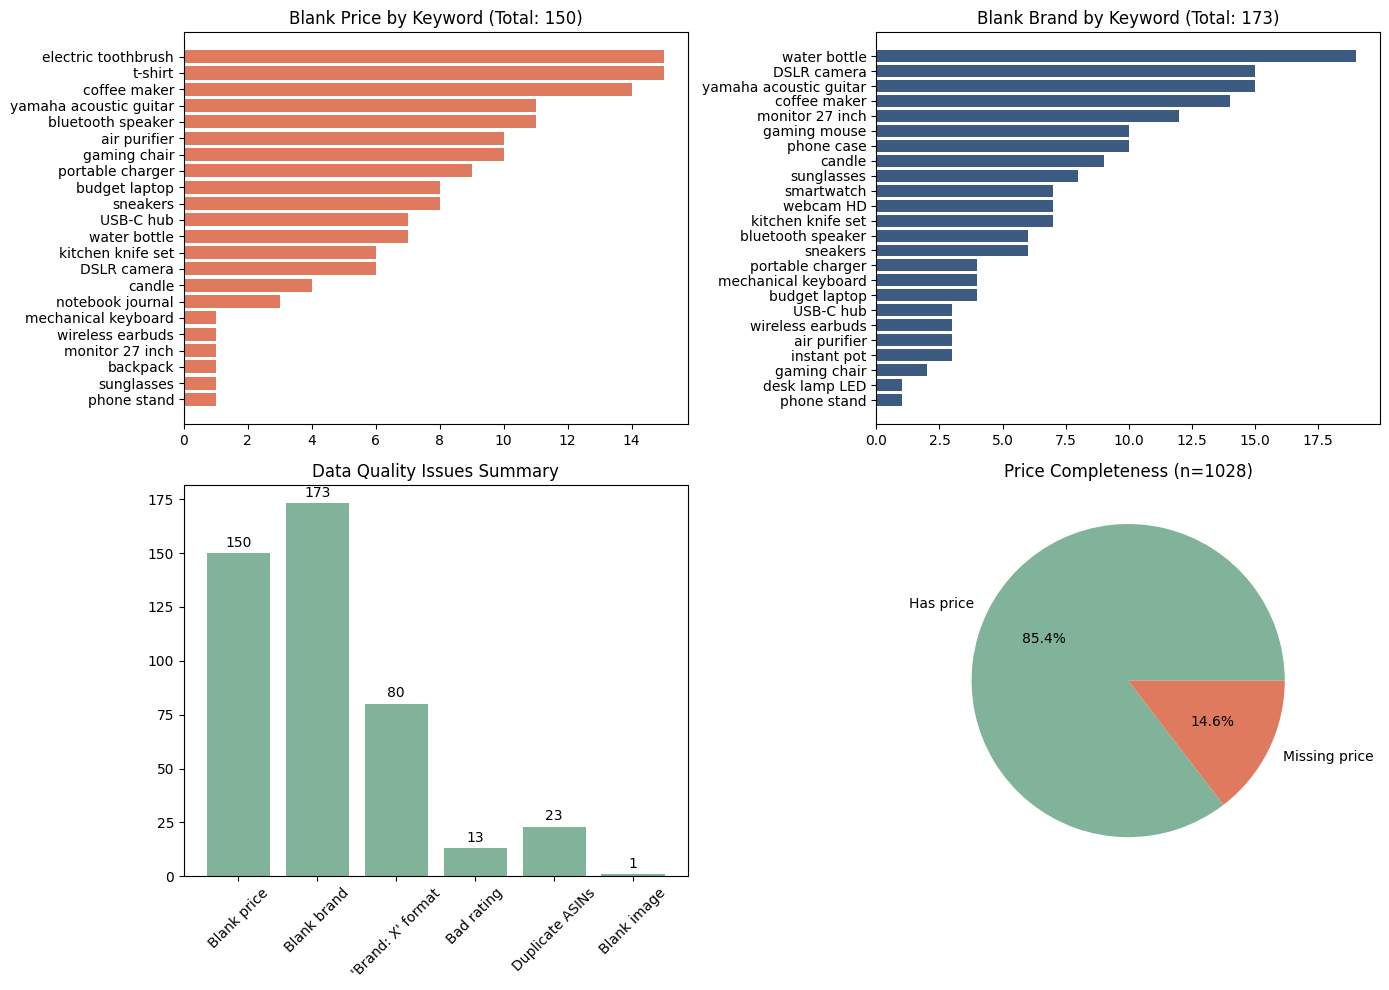

Duplicate ASINs: 23
Rows with 'Brand: X' recoverable format: 80


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Blank price by keyword
blank_price = df[df["price"] == ""]["search_keyword"].value_counts()
axes[0, 0].barh(blank_price.index, blank_price.values, color="#e07a5f")
axes[0, 0].set_title(f"Blank Price by Keyword (Total: {len(df[df['price']==''])})")
axes[0, 0].invert_yaxis()

# 2. Blank brand by keyword
blank_brand = df[df["brand"] == ""]["search_keyword"].value_counts()
axes[0, 1].barh(blank_brand.index, blank_brand.values, color="#3d5a80")
axes[0, 1].set_title(f"Blank Brand by Keyword (Total: {len(df[df['brand']==''])})")
axes[0, 1].invert_yaxis()

# 3. Data quality summary bar
issues = {
    "Blank price": (df["price"] == "").sum(),
    "Blank brand": (df["brand"] == "").sum(),
    "'Brand: X' format": df["brand"].str.startswith("Brand:", na=False).sum(),
    "Bad rating": (~df["rating"].str.contains("out of 5 stars", na=False)).sum(),
    "Duplicate ASINs": (df["asin"].value_counts() > 1).sum(),
    "Blank image": (df["main_image_url"] == "").sum(),
}
axes[1, 0].bar(issues.keys(), issues.values(), color="#81b29a")
axes[1, 0].set_title("Data Quality Issues Summary")
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(issues.values()):
    axes[1, 0].text(i, v + 3, str(v), ha='center')

# 4. Overall completeness pie
total = len(df)
clean_price = total - issues["Blank price"]
axes[1, 1].pie([clean_price, issues["Blank price"]], labels=["Has price", "Missing price"],
               autopct='%1.1f%%', colors=["#81b29a", "#e07a5f"])
axes[1, 1].set_title(f"Price Completeness (n={total})")

plt.tight_layout()
plt.show()

print("Duplicate ASINs:", (df["asin"].value_counts() > 1).sum())
print("Rows with 'Brand: X' recoverable format:", df["brand"].str.startswith("Brand:", na=False).sum())

# **Fix brand formatting**

In [15]:
import re

def clean_brand(brand):
    if not brand:
        return brand
    brand = brand.replace("Visit the ", "").replace(" Store", "")
    brand = re.sub(r"^Brand:\s*", "", brand)
    return brand.strip()

df["brand_clean"] = df["brand"].apply(clean_brand)

print("Before vs after, for the rows that had 'Brand: X' format:")
sample = df[df["brand"].str.startswith("Brand:", na=False)][["asin", "brand", "brand_clean"]].head(10)
display(sample)

print(f"\nBlank brand before: {(df['brand'] == '').sum()}")
print(f"Blank brand after:  {(df['brand_clean'] == '').sum()}")

Before vs after, for the rows that had 'Brand: X' format:


,asin,brand,brand_clean
2,B0H9LHWBDK,Brand: XIAOWTEK,XIAOWTEK
8,B0HBW8PTYN,Brand: Fhumsh,Fhumsh
9,B0HDB6MTYJ,Brand: Fhumsh,Fhumsh
10,B0H9LRGB3B,Brand: XIAOWTEK,XIAOWTEK
28,B0GWPXKLHB,Brand: WYQQXZYKJ,WYQQXZYKJ
33,B0DP3VPWN3,Brand: YOTETION,YOTETION
103,B0GZZVM9DX,Brand: ProTVSolutions,ProTVSolutions
125,B0GSZBDJ85,Brand: Tecival,Tecival
128,B0H14P6BZZ,Brand: Ciunedr,Ciunedr
133,B0FTL9CR3T,Brand: Generic,Generic



Blank brand before: 173
Blank brand after:  173


# **Clean price column**

In [17]:
def clean_price(price):
    if not price:
        return None
    match = re.search(r"[\d,]+\.\d{2}", price)
    if match:
        return float(match.group().replace(",", ""))
    return None

df["price_clean"] = df["price"].apply(clean_price)

print("Sample before/after:")
display(df[["asin", "price", "price_clean"]].head(10))

print(f"\nBlank price before: {(df['price'] == '').sum()}")
print(f"Missing price after (NaN): {df['price_clean'].isna().sum()}")
print(f"\nprice_clean dtype: {df['price_clean'].dtype}")

Sample before/after:


,asin,price,price_clean
0,B0D2HJDH94,$19.99,19.99
1,B09JYJ6JKH,$27.99,27.99
2,B0H9LHWBDK,$19.99,19.99
3,B0H7R1LD7B,$23.98,23.98
4,B0G7H6K1WN,$16.99,16.99
5,B0HBVXBZPZ,$16.99,16.99
6,B0FLJYT87N,$21.99,21.99
7,B0H5W2YR99,$23.98,23.98
8,B0HBW8PTYN,$19.99,19.99
9,B0HDB6MTYJ,$19.98,19.98



Blank price before: 150
Missing price after (NaN): 150

price_clean dtype: float64


# **Impute missing prices by category**

In [18]:
category_medians = df.groupby("search_keyword")["price_clean"].transform("median")
df["price_imputed"] = df["price_clean"].fillna(category_medians)

still_missing = df["price_imputed"].isna().sum()
print(f"Missing before imputation: {df['price_clean'].isna().sum()}")
print(f"Missing after imputation:  {still_missing}")

if still_missing > 0:
    print("\nKeywords where ALL products are missing price (can't impute):")
    print(df[df["price_imputed"].isna()]["search_keyword"].unique())

print("\n--- Verification: DSLR camera example ---")
print("DSLR camera known prices (stats):")
display(df[df["search_keyword"] == "DSLR camera"]["price_clean"].describe())

print("\nDSLR camera rows that were missing, before vs after:")
display(df[(df["search_keyword"] == "DSLR camera") & (df["price_clean"].isna())]
        [["asin", "title", "price_clean", "price_imputed"]])

Missing before imputation: 150
Missing after imputation:  0

--- Verification: DSLR camera example ---
DSLR camera known prices (stats):


count      13.000000
mean      386.841538
std       374.855635
min        16.980000
25%        89.990000
50%       244.990000
75%       549.000000
max      1328.840000
Name: price_clean, dtype: float64


DSLR camera rows that were missing, before vs after:


,asin,title,price_clean,price_imputed
439,B0101RW3QK,Canon EOS Rebel T7 DSLR Camera Double Zoom Len...,NaN,244.99
443,B0B9BLHWB8,"KODAK PIXPRO AZ528 16MP Digital Camera, 52x Op...",NaN,244.99
447,B086TTTZR5,Canon EOS RP Full-Frame Mirrorless Interchange...,NaN,244.99
449,B09ZRN1N3Z,"KODAK PIXPRO FZ55 16MP Compact Digital Camera,...",NaN,244.99
451,B0BL7ZVY78,Canon EOS R6 Mark II Mirrorless Camera (Body O...,NaN,244.99
452,B0BTTV6CT1,Canon EOS R50 Mirrorless Camera RF-S18-45mm F4...,NaN,244.99


# **Flag imputed prices**

In [19]:
df["price_was_imputed"] = df["price_clean"].isna()

print("Imputation flag counts:")
print(df["price_was_imputed"].value_counts())

print("\nSample of flagged rows:")
display(df[df["price_was_imputed"]][["asin", "search_keyword", "price_clean", "price_imputed", "price_was_imputed"]].head(5))

Imputation flag counts:
price_was_imputed
False    878
True     150
Name: count, dtype: int64

Sample of flagged rows:


,asin,search_keyword,price_clean,price_imputed,price_was_imputed
17,B0D9R4GYTN,wireless earbuds,NaN,21.97,True
46,B0DXJQT19B,USB-C hub,NaN,32.99,True
48,B0DKT8BB4M,USB-C hub,NaN,32.99,True
49,B0F5HSNDXF,USB-C hub,NaN,32.99,True
58,B087QZVQJX,USB-C hub,NaN,32.99,True


# **review_count**

In [20]:
print("Sample review_count values and types:")
display(df[["asin", "review_count"]].head(10))

print(f"\nreview_count dtype: {df['review_count'].dtype}")
print(f"Any blank strings: {(df['review_count'] == '').sum()}")

def clean_review_count(count):
    if not count:
        return None
    try:
        return int(str(count).replace(",", ""))
    except ValueError:
        return None

df["review_count_clean"] = df["review_count"].apply(clean_review_count)

print(f"\nreview_count_clean dtype: {df['review_count_clean'].dtype}")
print(f"Missing after cleaning: {df['review_count_clean'].isna().sum()}")
display(df[["asin", "review_count", "review_count_clean"]].head(10))

Sample review_count values and types:


,asin,review_count
0,B0D2HJDH94,16257
1,B09JYJ6JKH,2856
2,B0H9LHWBDK,763
3,B0H7R1LD7B,343
4,B0G7H6K1WN,346
5,B0HBVXBZPZ,109
6,B0FLJYT87N,1089
7,B0H5W2YR99,343
8,B0HBW8PTYN,93
9,B0HDB6MTYJ,197



review_count dtype: object
Any blank strings: 16

review_count_clean dtype: float64
Missing after cleaning: 16


,asin,review_count,review_count_clean
0,B0D2HJDH94,16257,16257.0
1,B09JYJ6JKH,2856,2856.0
2,B0H9LHWBDK,763,763.0
3,B0H7R1LD7B,343,343.0
4,B0G7H6K1WN,346,346.0
5,B0HBVXBZPZ,109,109.0
6,B0FLJYT87N,1089,1089.0
7,B0H5W2YR99,343,343.0
8,B0HBW8PTYN,93,93.0
9,B0HDB6MTYJ,197,197.0


# **Remove duplicate ASINs**

In [21]:
print(f"Rows before deduplication: {len(df)}")

df_deduped = df.drop_duplicates(subset="asin", keep="first")

print(f"Rows after deduplication: {len(df_deduped)}")
print(f"Rows removed: {len(df) - len(df_deduped)}")

df = df_deduped.reset_index(drop=True)
print(f"\nFinal row count: {len(df)}")

Rows before deduplication: 1028
Rows after deduplication: 1005
Rows removed: 23

Final row count: 1005


# **Clean rating column**

In [22]:
def clean_rating(rating):
    match = re.search(r"([\d.]+)\s*out of 5 stars", str(rating))
    if match:
        return float(match.group(1))
    return None

df["rating_clean"] = df["rating"].apply(clean_rating)

print(f"Missing/invalid ratings: {df['rating_clean'].isna().sum()}")
display(df[df["rating_clean"].isna()][["asin", "search_keyword", "rating"]])

print("\nSample before/after:")
display(df[["asin", "rating", "rating_clean"]].head(10))
print(f"\nrating_clean stats:")
display(df["rating_clean"].describe())

Missing/invalid ratings: 13


,asin,search_keyword,rating
320,B0GVPQNGS8,budget laptop,
325,B0GY16ZXZV,budget laptop,
341,B0GM8RB7P7,budget laptop,
351,B0HDN8K6GB,bluetooth speaker,
356,B0H7X6X3CR,bluetooth speaker,
375,B0H25NYHZS,kitchen knife set,
407,B0HC7CLS4G,kitchen knife set,
444,B0H42JFSHP,coffee maker,
604,B0GSH59RLD,water bottle,
725,B0HCMZP9H1,notebook journal,



Sample before/after:


,asin,rating,rating_clean
0,B0D2HJDH94,4.3 out of 5 stars,4.3
1,B09JYJ6JKH,4.0 out of 5 stars,4.0
2,B0H9LHWBDK,4.6 out of 5 stars,4.6
3,B0H7R1LD7B,4.6 out of 5 stars,4.6
4,B0G7H6K1WN,4.7 out of 5 stars,4.7
5,B0HBVXBZPZ,4.9 out of 5 stars,4.9
6,B0FLJYT87N,4.4 out of 5 stars,4.4
7,B0H5W2YR99,4.6 out of 5 stars,4.6
8,B0HBW8PTYN,5.0 out of 5 stars,5.0
9,B0HDB6MTYJ,5.0 out of 5 stars,5.0



rating_clean stats:


count    992.000000
mean       4.465323
std        0.248115
min        3.000000
25%        4.400000
50%        4.500000
75%        4.600000
max        5.000000
Name: rating_clean, dtype: float64

# **Check for missing image URLs**

In [23]:
print(f"Blank main_image_url: {(df['main_image_url'] == '').sum()}")
display(df[df["main_image_url"] == ""][["asin", "search_keyword", "title"]])

Blank main_image_url: 1


,asin,search_keyword,title
810,B000I9VON0,sneakers,


# **Verify no-rating products have zero reviews**

In [24]:
print("The 13 rows with missing rating - checking review counts too:")
display(df[df["rating_clean"].isna()][["asin", "search_keyword", "rating_clean", "review_count_clean", "reviews"]])

The 13 rows with missing rating - checking review counts too:


,asin,search_keyword,rating_clean,review_count_clean,reviews
320,B0GVPQNGS8,budget laptop,NaN,NaN,[]
325,B0GY16ZXZV,budget laptop,NaN,NaN,[]
341,B0GM8RB7P7,budget laptop,NaN,NaN,[]
351,B0HDN8K6GB,bluetooth speaker,NaN,NaN,[]
356,B0H7X6X3CR,bluetooth speaker,NaN,NaN,[]
375,B0H25NYHZS,kitchen knife set,NaN,NaN,[]
407,B0HC7CLS4G,kitchen knife set,NaN,NaN,[]
444,B0H42JFSHP,coffee maker,NaN,NaN,[]
604,B0GSH59RLD,water bottle,NaN,NaN,[]
725,B0HCMZP9H1,notebook journal,NaN,NaN,[]


# **Flag products with a usable image**

In [26]:
df["has_image"] = df["main_image_url"] != ""

print(f"Products with a usable image: {df['has_image'].sum()} / {len(df)}")
print(f"Products missing an image: {(~df['has_image']).sum()}")

display(df[~df["has_image"]][["asin", "search_keyword", "title", "main_image_url", "has_image"]])

Products with a usable image: 1004 / 1005
Products missing an image: 1


,asin,search_keyword,title,main_image_url,has_image
810,B000I9VON0,sneakers,,,False


# **Flag products with missing rating**

In [30]:
df["rating_missing"] = df["rating_clean"].isna()
print(f"Flagged {df['rating_missing'].sum()} products as having no rating.")
print(df.columns.tolist())

Flagged 13 products as having no rating.
['search_keyword', 'asin', 'title', 'brand', 'price', 'rating', 'review_count', 'bullet_points', 'main_image_url', 'video_urls', 'reviews', 'brand_clean', 'price_clean', 'price_imputed', 'price_was_imputed', 'review_count_clean', 'rating_clean', 'has_image', 'rating_missing']


# **Assemble final dataframe**

In [31]:
final_columns = [
    "search_keyword", "asin", "title", "brand_clean",
    "price_clean", "price_imputed", "price_was_imputed",
    "rating_clean", "rating_missing",
    "review_count_clean",
    "bullet_points", "main_image_url", "has_image",
    "video_urls", "reviews"
]

df_final = df[final_columns].copy()
df_final = df_final.rename(columns={
    "brand_clean": "brand",
    "price_imputed": "price",
    "rating_clean": "rating",
    "review_count_clean": "review_count",
})

print(f"Final cleaned dataset: {len(df_final)} products, {len(df_final.columns)} columns")
df_final.info()

Final cleaned dataset: 1005 products, 15 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   search_keyword     1005 non-null   object 
 1   asin               1005 non-null   object 
 2   title              1005 non-null   object 
 3   brand              1005 non-null   object 
 4   price_clean        856 non-null    float64
 5   price              1005 non-null   float64
 6   price_was_imputed  1005 non-null   bool   
 7   rating             992 non-null    float64
 8   rating_missing     1005 non-null   bool   
 9   review_count       989 non-null    float64
 10  bullet_points      1005 non-null   object 
 11  main_image_url     1005 non-null   object 
 12  has_image          1005 non-null   bool   
 13  video_urls         1005 non-null   object 
 14  reviews            1005 non-null   object 
dtypes: bool(3), float64(4),

# **Detect review language**

In [32]:
%pip install langdetect -q

from langdetect import detect, LangDetectException

def detect_language(text):
    if not text or not text.strip():
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

all_reviews = []
for idx, row in df_final.iterrows():
    for review in row["reviews"]:
        all_reviews.append({
            "product_idx": idx,
            "asin": row["asin"],
            "body": review.get("body", ""),
        })

reviews_df = pd.DataFrame(all_reviews)
reviews_df["language"] = reviews_df["body"].apply(detect_language)

print(f"Total reviews: {len(reviews_df)}")
print("\nLanguage breakdown:")
display(reviews_df["language"].value_counts())

non_english = reviews_df[reviews_df["language"] != "en"]
print(f"\nNon-English reviews: {len(non_english)} ({len(non_english)/len(reviews_df)*100:.1f}%)")

Note: you may need to restart the kernel to use updated packages.
Total reviews: 11288

Language breakdown:


language
en         9385
es          751
fr          239
pt          162
de          153
it          102
ar           98
ja           65
ca           36
nl           34
ro           29
sv           28
tr           26
af           26
so           24
pl           19
no           18
unknown      16
da           10
sl            8
id            7
hu            6
et            6
cy            6
ur            5
tl            5
fi            5
fa            4
sk            3
sw            3
vi            2
cs            2
lt            1
hr            1
lv            1
sq            1
ko            1
Name: count, dtype: int64


Non-English reviews: 1903 (16.9%)


# **Visualize language detection results**

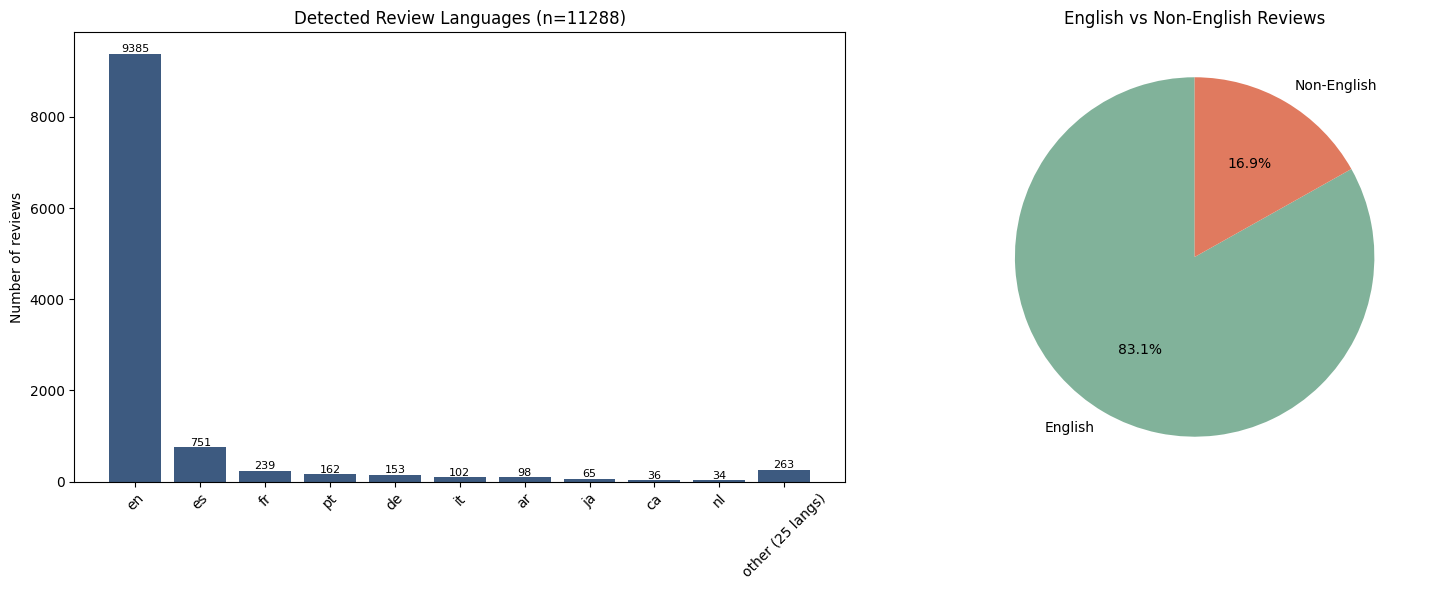

English: 9385 (83.1%)
Non-English: 1903 (16.9%)
Languages detected: 37


In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lang_counts = reviews_df["language"].value_counts()
top_langs = lang_counts.head(10)
others = lang_counts.iloc[10:].sum()
plot_data = pd.concat([top_langs, pd.Series({"other (25 langs)": others})])

axes[0].bar(plot_data.index, plot_data.values, color="#3d5a80")
axes[0].set_title(f"Detected Review Languages (n={len(reviews_df)})")
axes[0].set_ylabel("Number of reviews")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(plot_data.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=8)

en_count = (reviews_df["language"] == "en").sum()
non_en_count = len(reviews_df) - en_count
axes[1].pie([en_count, non_en_count], labels=["English", "Non-English"],
            autopct='%1.1f%%', colors=["#81b29a", "#e07a5f"], startangle=90)
axes[1].set_title("English vs Non-English Reviews")

plt.tight_layout()
plt.show()

print(f"English: {en_count} ({en_count/len(reviews_df)*100:.1f}%)")
print(f"Non-English: {non_en_count} ({non_en_count/len(reviews_df)*100:.1f}%)")
print(f"Languages detected: {reviews_df['language'].nunique()}")

# **Check rare-language rows for false positives**

In [33]:
print("Sample of unusual/rare detected languages - checking for false positives:")
display(reviews_df[reviews_df["language"].isin(["ca", "af", "so", "cy", "unknown"])][["asin", "body", "language"]].head(15))

Sample of unusual/rare detected languages - checking for false positives:


,asin,body,language
65,B0HBVXBZPZ,Excellent,ca
279,B011HMDZ0Q,idk ho to write gourges xddd But its sooo gooo...,af
405,B0F1D7P51F,goeie muis niet meer leverbaar.!,af
466,B0GZY5VR22,,unknown
471,B0GZY5VR22,Very good,af
640,B0BL9F5S6R,good,so
720,B0874M3KW4,As per description,ca
767,B0D14N2QZF,Good,so
806,B08Z6X4NK3,Very good,af
944,B0C8QYB8W6,Awesome keyboard!,af


# **Translate non-English reviews**

In [38]:
%pip install deep-translator -q

from deep_translator import GoogleTranslator

MIN_LENGTH_FOR_DETECTION = 20

def needs_translation(row):
    if row["language"] == "en" or row["language"] == "unknown":
        return False
    if len(row["body"].strip()) < MIN_LENGTH_FOR_DETECTION:
        return False
    return True

reviews_df["needs_translation"] = reviews_df.apply(needs_translation, axis=1)
print(f"Reviews flagged for translation (after short-text filter): {reviews_df['needs_translation'].sum()}")
print(f"Removed as likely false positives (too short): {(reviews_df['language'] != 'en').sum() - reviews_df['needs_translation'].sum()}")

def translate_text(text, source_lang):
    try:
        return GoogleTranslator(source=source_lang, target="en").translate(text)
    except Exception:
        return text

reviews_df["body_en"] = reviews_df["body"]

for i, (idx, row) in enumerate(to_translate.iterrows()):
    reviews_df.at[idx, "body_en"] = translate_text(row["body"], row["language"])
    if (i + 1) % 100 == 0:
        print(f"Translated {i + 1}/{len(to_translate)}")

print(f"\nDone. Translated {len(to_translate)} reviews.")

changed = (reviews_df.loc[to_translate.index, "body"] != reviews_df.loc[to_translate.index, "body_en"]).sum()
print(f"Rows where body_en actually differs from body: {changed} / {len(to_translate)}")

display(reviews_df.loc[to_translate.index, ["asin", "body", "body_en", "language"]].head(10))

Note: you may need to restart the kernel to use updated packages.
Reviews flagged for translation (after short-text filter): 1531
Removed as likely false positives (too short): 372
Translated 100/1531
Translated 200/1531
Translated 300/1531
Translated 400/1531
Translated 500/1531
Translated 600/1531
Translated 700/1531
Translated 800/1531
Translated 900/1531
Translated 1000/1531
Translated 1100/1531
Translated 1200/1531
Translated 1300/1531
Translated 1400/1531
Translated 1500/1531

Done. Translated 1531 reviews.
Rows where body_en actually differs from body: 428 / 1531


,asin,body,body_en,language
9,B0D2HJDH94,Excellent prix et durabilité,Excellent price and durability,fr
10,B0D2HJDH94,+ Soundqualität Das Wichtigste bei jeder Art v...,"+ Sound quality Of course, at the end of the d...",de
21,B09JYJ6JKH,البطارية بتقعد ساعة وحدة وبتخلص,The battery lasts for one hour and then dies,ar
30,B0H9LHWBDK,De finns egentligen inte mycket att säga förut...,There really isn't much to say about them othe...,sv
32,B0H9LHWBDK,J'ai acheté ce casque sans fil comme solution ...,I purchased this wireless headset as a stopgap...,fr
33,B0H9LHWBDK,Als stolzer Besitzer der Bluetooth Kopfhörer k...,"As a proud owner of the Bluetooth headphones, ...",de
34,B0H9LHWBDK,J'ai acheté ces écouteurs pour faire un cadeau...,I bought these headphones as a gift a while ag...,fr
77,B0FLJYT87N,El producto es el segundo que compro igual exc...,The product is the second one I have purchased...,es
78,B0FLJYT87N,Parfait je suis contente de mon achat. Bonne c...,"Perfect, I am happy with my purchase. Good cha...",fr
79,B0FLJYT87N,Hace bastante tiempo que los tengo y van genia...,I've had them for quite some time and they loo...,es


# **Diagnose unchanged (failed) translations**

In [39]:
unchanged = reviews_df.loc[to_translate.index]
unchanged = unchanged[unchanged["body"] == unchanged["body_en"]]

print(f"Unchanged rows: {len(unchanged)}")
print("\nLanguage breakdown of unchanged rows:")
display(unchanged["language"].value_counts())

print("\nSample of unchanged rows:")
display(unchanged[["asin", "body", "body_en", "language"]].head(10))

Unchanged rows: 1103

Language breakdown of unchanged rows:


language
es    526
fr    157
de     94
pt     90
it     60
ar     48
ja     37
nl     19
sv     15
tr     13
pl     12
ca      6
no      6
da      4
ro      4
af      3
hu      3
et      2
sl      1
tl      1
vi      1
lv      1
Name: count, dtype: int64


Sample of unchanged rows:


,asin,body,body_en,language
143,B0F4MZBZRH,Ho acquistato gli auricolari Rolosar Q76 per u...,Ho acquistato gli auricolari Rolosar Q76 per u...,it
203,B07PBS21V8,O fone parou de funcionar em 3 meses. Péssimo ...,O fone parou de funcionar em 3 meses. Péssimo ...,pt
228,B0G1PJLWLZ,Formidable toutes les fonctions quand on a un ...,Formidable toutes les fonctions quand on a un ...,fr
243,B09FT58QQP,J'utilise ces tozo A1 pour écouter principalem...,J'utilise ces tozo A1 pour écouter principalem...,fr
253,B0FNRXZV67,Son muy buenos y calidad impecable,Son muy buenos y calidad impecable,es
541,B0BR3M8XHK,Este hub USB-C UGREEN Revodok 105 me ha result...,Este hub USB-C UGREEN Revodok 105 me ha result...,es
569,B0F5HSNDXF,"Muy buena calidad, cumple lo que dice.","Muy buena calidad, cumple lo que dice.",es
572,B0H1RRYP7S,Me ayudó a conectar un segundo monitor a mi Mi...,Me ayudó a conectar un segundo monitor a mi Mi...,es
587,B0G11F8FHR,Uso mi Mac Mini M1 (que sólo tiene 2 puertos u...,Uso mi Mac Mini M1 (que sólo tiene 2 puertos u...,es
588,B0G11F8FHR,"Buen diseño y funcionalidad, recomendable","Buen diseño y funcionalidad, recomendable",es


# **Retry failed translations with backoff**

In [41]:
def translate_with_retry(text, source_lang, retries=2, delay=0.3):
    for attempt in range(retries + 1):
        try:
            return GoogleTranslator(source=source_lang, target="en").translate(text)
        except Exception:
            time.sleep(delay * (attempt + 1))
    return text

still_unchanged = reviews_df.loc[to_translate.index]
still_unchanged = still_unchanged[still_unchanged["body"] == still_unchanged["body_en"]]

print(f"Retrying {len(still_unchanged)} failed translations...")

for i, (idx, row) in enumerate(still_unchanged.iterrows()):
    reviews_df.at[idx, "body_en"] = translate_with_retry(row["body"], row["language"])
    time.sleep(0.3)
    if (i + 1) % 100 == 0:
        print(f"Retried {i + 1}/{len(still_unchanged)}")

changed_now = (reviews_df.loc[to_translate.index, "body"] != reviews_df.loc[to_translate.index, "body_en"]).sum()
print(f"\nTotal successfully translated (out of {len(to_translate)}): {changed_now}")

still_failed = reviews_df.loc[to_translate.index]
still_failed = still_failed[still_failed["body"] == still_failed["body_en"]]
print(f"Still unchanged after retry: {len(still_failed)}")
if len(still_failed) > 0:
    display(still_failed["language"].value_counts())

Retrying 1103 failed translations...
Retried 100/1103
Retried 200/1103
Retried 300/1103
Retried 400/1103
Retried 500/1103
Retried 600/1103
Retried 700/1103
Retried 800/1103
Retried 900/1103
Retried 1000/1103
Retried 1100/1103

Total successfully translated (out of 1531): 1396
Still unchanged after retry: 135


language
es    48
pt    16
fr    16
de     7
it     6
nl     6
ca     5
ar     5
no     4
ro     4
da     4
af     2
pl     2
sv     2
ja     2
sl     1
vi     1
tl     1
lv     1
hu     1
et     1
Name: count, dtype: int64

# **Final retry on remaining untranslated reviews**

In [42]:
final_retry = reviews_df.loc[to_translate.index]
final_retry = final_retry[final_retry["body"] == final_retry["body_en"]]

print(f"Final retry on {len(final_retry)} remaining...")

for i, (idx, row) in enumerate(final_retry.iterrows()):
    reviews_df.at[idx, "body_en"] = translate_with_retry(row["body"], row["language"], retries=3, delay=0.5)
    time.sleep(0.5)

final_changed = (reviews_df.loc[to_translate.index, "body"] != reviews_df.loc[to_translate.index, "body_en"]).sum()
print(f"\nFinal total translated: {final_changed} / {len(to_translate)}")

truly_failed = reviews_df.loc[to_translate.index]
truly_failed = truly_failed[truly_failed["body"] == truly_failed["body_en"]]
print(f"Truly untranslatable (kept as original): {len(truly_failed)}")

Final retry on 135 remaining...

Final total translated: 1492 / 1531
Truly untranslatable (kept as original): 39


# **Verify translation merged correctly**

In [44]:
translated_asins = reviews_df[reviews_df["body"] != reviews_df["body_en"]]["asin"].unique()
check_asin = translated_asins[0]

check_row = df_final[df_final["asin"] == check_asin].iloc[0]
for r in check_row["reviews"]:
    if r["body"] != r["body_en"]:
        print(f"asin: {check_asin}")
        print(f"body:    {r['body'][:100]}")
        print(f"body_en: {r['body_en'][:100]}")
        break

asin: B0D2HJDH94
body:    Excellent prix et durabilité
body_en: Excellent price and durability


# **Save cleaned dataset (JSON + CSV)**

In [45]:
CLEANED_DIR = Path("amazon-product-intelligence/data/cleaned")
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

json_path = CLEANED_DIR / "products_cleaned.json"
csv_path = CLEANED_DIR / "products_cleaned.csv"

df_final.to_json(json_path, orient="records", indent=2, force_ascii=False)

df_csv = df_final.copy()
df_csv["bullet_points"] = df_csv["bullet_points"].apply(lambda x: json.dumps(x, ensure_ascii=False))
df_csv["video_urls"] = df_csv["video_urls"].apply(lambda x: json.dumps(x, ensure_ascii=False))
df_csv["reviews"] = df_csv["reviews"].apply(lambda x: json.dumps(x, ensure_ascii=False))
df_csv.to_csv(csv_path, index=False)

print(f"Saved: {json_path}")
print(f"Saved: {csv_path}")

Saved: amazon-product-intelligence/data/cleaned/products_cleaned.json
Saved: amazon-product-intelligence/data/cleaned/products_cleaned.csv
